In [1]:
from fdm_edl.edl.system import ElectricalDoubleLayer

import jax.numpy as jnp
import matplotlib.pyplot as plt

import gmsh

In [2]:
gmsh.initialize()

gmsh.model.add("MultiComponent1D")
# We use the OpenCASCADE kernel for geometry
occ = gmsh.model.occ

# Define Points (x, y, z, mesh_size)
p1 = occ.addPoint(0, 0, 0, 0.01)
p2 = occ.addPoint(1.0, 0, 0, 0.05)
# Define Lines
line = occ.addLine(p1, p2)

# ask gmsh to synchronize the CAD kernel with the Gmsh model before meshing
occ.synchronize()
# Generate 1D Mesh
gmsh.model.mesh.generate(1)

# Get all node tags and their coordinates
_node_tags, _meshes, _ = gmsh.model.mesh.getNodes()
# Reshape coords: Gmsh gives [x1, y1, z1, x2, y2, z2...]
# We turn it into a (N, 3) array
meshes = _meshes.reshape(-1, 3)

gmsh.finalize()

Info    : Meshing 1D...
Info    : Meshing curve 1 (Line)
Info    : Done meshing 1D (Wall 0.0033186s, CPU 0.003458s)
Info    : 42 nodes 43 elements


In [3]:
edl_obj = ElectricalDoubleLayer("input.json")
# 0.1 V vs pzc
phi_final = edl_obj.compute(jnp.sort(meshes[:, 0]), 0.1)

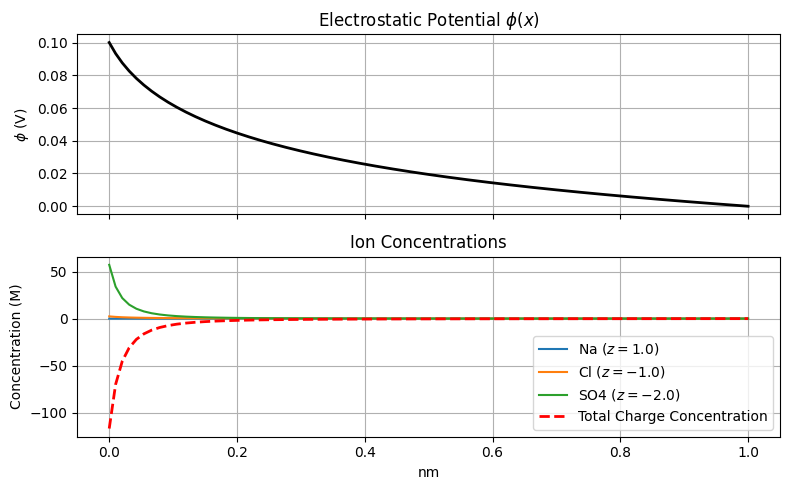

In [4]:
fig, axs = edl_obj.plot()

plt.show()